In [1]:
import torch
import warnings
import pop_tools
import numpy as np
import xesmf as xe
import pandas as pd
import xarray as xr
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
torch.amp.autocast('cuda')
warnings.filterwarnings("ignore", message="Latitude is outside of \\[-90, 90\\]")

print("Number of GPUs:", torch.cuda.device_count())

Number of GPUs: 1


#### Data preparation

In [2]:
# ------------------------------
# Set up training & testing data
# ------------------------------

X = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/X_perfmodexp.nc').X
Y = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/Y_perfmodexp.nc').Y

# Select data
llat, llon = X.lat.values, X.lon.values
hlat, hlon = Y.lat.values, Y.lon.values

X = X.values
Y = Y.values

# Clip to max thickness (remove spurious CESM1 artifacts)
X = np.clip(X, None, 6.0)
Y = np.clip(Y, None, 6.0)

# ------------------------------
# Land-sea mask
# ------------------------------

high_src = pop_tools.get_grid('POP_tx0.1v2')
mask_native = (high_src.KMT > 0).astype(np.float32)

rows_high = np.where(np.any(high_src.TLAT >= 40, axis=1))[0]
jmin_high = rows_high.min()

mask_sel = mask_native.isel(nlat=slice(jmin_high, None))

lat_high = high_src.TLAT.isel(nlat=slice(jmin_high, None))
lon_high = high_src.TLONG.isel(nlat=slice(jmin_high, None))

src_grid_high = xr.Dataset(
    {"lat": (["nlat", "nlon"], lat_high.data),
     "lon": (["nlat", "nlon"], lon_high.data)}
)

dst_grid_hr = xr.Dataset(
    {"lat": (["lat"], np.arange(40, 90.001, 0.1)),
     "lon": (["lon"], np.arange(0, 360, 0.1))}
)

regridder_high = xe.Regridder(
    src_grid_high,
    dst_grid_hr,
    periodic=True,
    method="bilinear",
    filename="tx0.1v2_to_latlon_0.1deg.nc",
    reuse_weights=True
)

mask_reg = regridder_high(mask_sel)

# Convert back to binary
land_mask = (mask_reg < 0.5).astype(np.float32)

bbox = {"lon_min": -130, "lon_max": -80, "lat_min": 60, "lat_max": 80}
lon_min = bbox["lon_min"] % 360
lon_max = bbox["lon_max"] % 360

land_mask = land_mask.sel(lat=slice(bbox["lat_min"], bbox["lat_max"]), lon=slice(lon_min, lon_max))
land_mask = torch.from_numpy(land_mask.values).float()[None, None, ...]

print(X.shape, Y.shape, land_mask.shape)

(10, 1032, 5, 21, 51) (10, 1032, 1, 200, 501) torch.Size([1, 1, 200, 501])


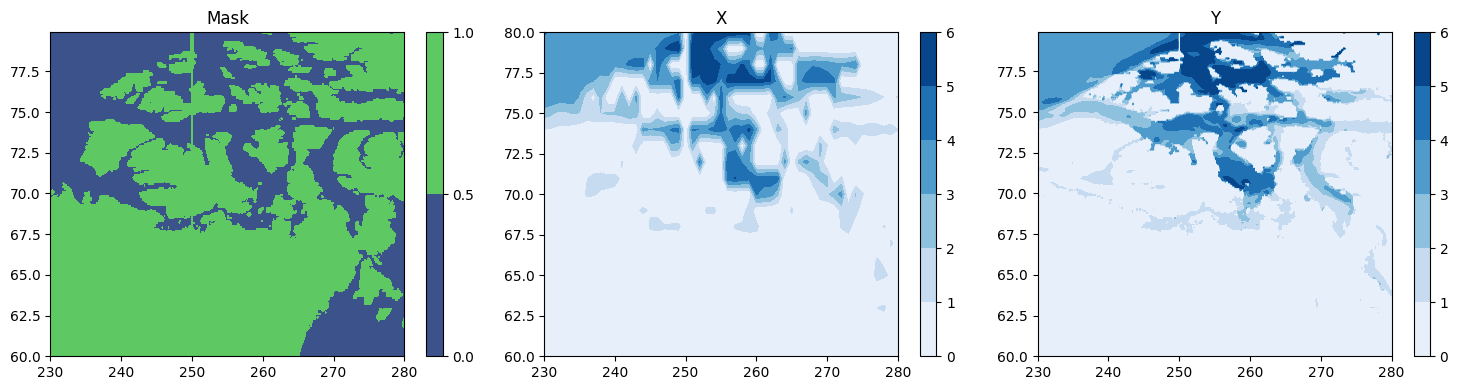

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
levels = np.linspace(0, 6, 7)

cf1 = axes[0].contourf(hlon, hlat, land_mask[0, 0], levels=[0, 0.5, 1])
fig.colorbar(cf1, ax=axes[0])
axes[0].set_title("Mask")

cf2 = axes[1].contourf(llon, llat, X[0, 0, 0], levels=levels, cmap='Blues')
fig.colorbar(cf2, ax=axes[1])
axes[1].set_title("X")

cf3 = axes[2].contourf(hlon, hlat, Y[0, 0, 0], levels=levels, cmap='Blues')
fig.colorbar(cf3, ax=axes[2])
axes[2].set_title("Y")

plt.tight_layout()
plt.show()

In [13]:
# ------------------------------
# Patch Extraction
# ------------------------------

def extract_patches(X, Y, mask, context_size, target_size, stride):

    N, C, H, W = X.shape
    _, C_out, H_hi, W_hi = Y.shape

    context_h, context_w = context_size
    target_h, target_w = target_size

    # Sanity checks
    if context_h > H or context_w > W:
        raise ValueError(f"Context size {context_size} exceeds LR grid size ({H}, {W})")

    if target_h > context_h or target_w > context_w:
        raise ValueError(f"Target size {target_size} must be <= context size {context_size}")

    # LR to HR scaling factors
    scale_y = H_hi / H
    scale_x = W_hi / W

    # Padding around center target region
    pad_h = (context_h - target_h) // 2
    pad_w = (context_w - target_w) // 2

    X_patches = []
    Y_patches = []
    M_patches = []

    for n in range(N):
        for i in range(0, H - context_h + 1, stride):
            for j in range(0, W - context_w + 1, stride):

                x_patch = X[n, :, i:i + context_h, j:j + context_w]

                y0 = round((i + pad_h) * scale_y)
                x0 = round((j + pad_w) * scale_x)

                y1 = y0 + int(round(target_h * scale_y))
                x1 = x0 + int(round(target_w * scale_x))

                y_patch = Y[n, :, y0:y1, x0:x1]

                mask_patch = mask[0, 0, y0:y1, x0:x1].unsqueeze(0)

                X_patches.append(x_patch)
                Y_patches.append(y_patch)
                M_patches.append(mask_patch)

    X_patches = torch.stack(X_patches)
    Y_patches = torch.stack(Y_patches)
    M_patches = torch.stack(M_patches)

    return X_patches, Y_patches, M_patches


# ------------------------------
# Train/Test Split
# ------------------------------

N, T, C, H, W = X.shape

X_fields = torch.tensor(X.reshape(N * T, C, H, W)).float()
Y_fields = torch.tensor(Y.reshape(N * T, 1, Y.shape[3], Y.shape[4])).float()

indices = torch.randperm(N * T)
split = int(0.7 * N * T)

train_idx = indices[:split]
test_idx = indices[split:]

X_train_fields = X_fields[train_idx]
Y_train_fields = Y_fields[train_idx]
X_test_fields = X_fields[test_idx]
Y_test_fields = Y_fields[test_idx]

# ------------------------------
# Normalize
# ------------------------------

X_mean = X_train_fields.mean(dim=(0, 2, 3), keepdim=True)
X_std = X_train_fields.std(dim=(0, 2, 3), keepdim=True)
Y_mean = Y_train_fields.mean(dim=(0, 2, 3), keepdim=True)
Y_std = Y_train_fields.std(dim=(0, 2, 3), keepdim=True)

X_train_fields = (X_train_fields - X_mean) / (X_std + 1e-6)
X_test_fields = (X_test_fields - X_mean) / (X_std + 1e-6)
Y_train_fields = (Y_train_fields - Y_mean) / (Y_std + 1e-6)
Y_test_fields = (Y_test_fields - Y_mean) / (Y_std + 1e-6)

# ------------------------------
# Extract Patches
# ------------------------------

context_size = (16, 24)
target_size = (8, 12)
stride = 4

X_train, Y_train, M_train = extract_patches(X_train_fields, Y_train_fields, land_mask, context_size, target_size, stride)
X_test, Y_test, _ = extract_patches(X_test_fields, Y_test_fields, land_mask, context_size, target_size, stride)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("M_train:", M_train.shape)
print("X_test: ", X_test.shape)
print("Y_test: ", Y_test.shape)

X_train: torch.Size([101136, 5, 16, 24])
Y_train: torch.Size([101136, 1, 76, 118])
M_train: torch.Size([101136, 1, 76, 118])
X_test:  torch.Size([43344, 5, 16, 24])
Y_test:  torch.Size([43344, 1, 76, 118])
M_test:  torch.Size([43344, 1, 76, 118])


#### Model setup

In [25]:
# ------------------------------
# UNet
# ------------------------------
def smooth_noise(z):
    return F.avg_pool2d(z, kernel_size=3, stride=1, padding=1)


class UNet(nn.Module):

    def __init__(self, in_channels, latent_channels=8):
        super().__init__()

        self.latent_channels = latent_channels

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.InstanceNorm2d(out_c, affine=True),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.InstanceNorm2d(out_c, affine=True),
                nn.ReLU(inplace=True),
            )

        # ------------------------------
        # Encoder
        # ------------------------------

        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = conv_block(256, 512)

        # ------------------------------
        # Bottleneck
        # ------------------------------

        # self.z_proj = nn.Conv2d(latent_channels, 512, 1)
        # self.noise_scale = nn.Parameter(torch.tensor(0.1))
        self.bottleneck = conv_block(512, 512)

        # ------------------------------
        # Decoder
        # ------------------------------

        self.up3 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), nn.Conv2d(512, 256, 3, padding=1))
        self.dec3 = conv_block(512, 256)

        self.up2 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), nn.Conv2d(256, 128, 3, padding=1))
        self.dec2 = conv_block(256, 128)

        self.up1 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), nn.Conv2d(128, 64, 3, padding=1))
        self.dec1 = conv_block(128, 64)

        # Decoder noise projections
        self.z_proj_d3 = nn.Conv2d(latent_channels, 256, 1)
        self.z_proj_d2 = nn.Conv2d(latent_channels, 128, 1)
        self.z_proj_d1 = nn.Conv2d(latent_channels, 64, 1)

        # Scaling for additive noise
        self.noise_scale_d3 = nn.Parameter(torch.tensor(0.05))
        self.noise_scale_d2 = nn.Parameter(torch.tensor(0.05))
        self.noise_scale_d1 = nn.Parameter(torch.tensor(0.05))

        # Concatenation adapters
        self.concat_d3 = nn.Conv2d(256 + 256, 256, 1)
        self.concat_d2 = nn.Conv2d(128 + 128, 128, 1)
        self.concat_d1 = nn.Conv2d(64 + 64, 64, 1)

        # ------------------------------
        # Output
        # ------------------------------
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=4)
        self.out_conv = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x, up_size, z=None):

        B, C, H, W = x.shape

        # Latent noise
        if z is None:
            z = torch.randn(B, self.latent_channels, H // 8, W // 8, device=x.device)
            z = smooth_noise(z)

        # ------------------------------
        # Encoder
        # ------------------------------

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # ------------------------------
        # Bottleneck
        # ------------------------------

        # zb = F.interpolate(z, size=e4.shape[-2:], mode='bilinear', align_corners=False)
        # zb = self.z_proj(zb)
        # b = e4 + self.noise_scale * zb
        b = self.bottleneck(e4)

        # ------------------------------
        # Decoder
        # ------------------------------

        d3 = self.up3(b)
        zd3 = F.interpolate(z, size=d3.shape[-2:], mode="bilinear", align_corners=False)
        zd3 = self.z_proj_d3(zd3)
        # d3 = d3 + self.noise_scale_d3 * zd3               # Uncomment for ADDITIVE NOISE
        d3 = self.concat_d3(torch.cat([d3, zd3], dim=1))  # Uncomment for CONCATENATED NOISE
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        zd2 = F.interpolate(z, size=d2.shape[-2:], mode="bilinear", align_corners=False)
        zd2 = self.z_proj_d2(zd2)
        # d2 = d2 + self.noise_scale_d2 * zd2               # Uncomment for ADDITIVE NOISE
        d2 = self.concat_d2(torch.cat([d2, zd2], dim=1))  # Uncomment for CONCATENATED NOISE
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        zd1 = F.interpolate(z, size=d1.shape[-2:], mode="bilinear", align_corners=False)
        zd1 = self.z_proj_d1(zd1)
        # d1 = d1 + self.noise_scale_d1 * zd1               # Uncomment for ADDITIVE NOISE
        d1 = self.concat_d1(torch.cat([d1, zd1], dim=1))  # Uncomment for CONCATENATED NOISE
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # ------------------------------
        # Output
        # ------------------------------

        out = self.final_up(d1)
        out = self.out_conv(out)
        out = F.interpolate(out, size=up_size, mode="bilinear", align_corners=False)

        # Residual prediction
        base = F.interpolate(x[:, 0:1], size=up_size, mode="bilinear", align_corners=False)

        return base + out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=X_train.shape[1], latent_channels=8)
model = nn.DataParallel(model).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Done!")

Done!


#### Training loop (Engression)

In [26]:
def energy_loss(preds, y, beta=1.0):
    """
    Energy-score loss used for stochastic prediction.

    Args:
        preds (torch.Tensor): Ensemble predictions of shape [B, K, C, H, W], where B is batch size and K is the number of stochastic samples.
        y (torch.Tensor): Ground-truth targets of shape [B, C, H, W].
        beta (float, optional): Power parameter of the energy score. Default is 1.

    Returns:
        torch.Tensor: Scalar energy-score loss.
    """

    B, K, C, H, W = preds.shape

    flat_preds = preds.reshape(B, K, -1)
    flat_y = y.reshape(B, 1, -1)

    EPS = 0.0 if float(beta).is_integer() else 1e-5

    # Average distance between each ensemble member and truth
    s1 = (torch.linalg.vector_norm(flat_preds - flat_y, ord=2, dim=2) + EPS).pow(beta).mean()

    # Average pairwise distance between ensemble members
    s2 = (torch.cdist(flat_preds, flat_preds, p=2) + EPS).pow(beta).mean() * K/(K-1)

    return s1 - 0.5 * s2


def land_loss(preds, land_mask):
    """
    Penalize positive ice thickness predicted over land.
    """
    land_mask = land_mask.to(preds.device).unsqueeze(1)

    return ((torch.relu(preds) * land_mask) ** 2).mean()


# ------------------------------
# Training loop
# ------------------------------
num_epochs = 20
batch_size = 32
K = 6
loss_array = []

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0.0
    idx = torch.randperm(X_train.size(0))

    for i in range(0, X_train.size(0), batch_size):

        optimizer.zero_grad()

        # Batch
        batch_idx = idx[i:i+batch_size]
        X_batch = X_train[batch_idx].to(device)
        Y_batch = Y_train[batch_idx].to(device)
        M_batch = M_train[batch_idx].to(device)

        B, C, H, W = X_batch.shape

        # Stochastic ensemble
        X_rep = X_batch.repeat_interleave(K, dim=0)
        z = torch.randn(B*K, model.module.latent_channels, H // 8, W // 8, device=device)

        preds = model(X_rep, Y_batch.shape[-2:], z=z)
        preds = preds.reshape(B, K, preds.shape[1], preds.shape[2], preds.shape[3])

        # Loss
        loss_energy = energy_loss(preds, Y_batch)
        loss_land = land_loss(preds, M_batch)
        loss = loss_energy + loss_land

        # Backprop
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        epoch_loss += loss.item() * B

        del X_batch, Y_batch, preds, loss

    epoch_loss /= X_train.size(0)
    loss_array.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.6f}")

Epoch 1/20 | Loss: 21.207210
Epoch 2/20 | Loss: 15.407264
Epoch 3/20 | Loss: 13.806424
Epoch 4/20 | Loss: 12.910182
Epoch 5/20 | Loss: 12.351143
Epoch 6/20 | Loss: 11.941384
Epoch 7/20 | Loss: 11.623059
Epoch 8/20 | Loss: 11.362637
Epoch 9/20 | Loss: 11.141112
Epoch 10/20 | Loss: 10.952281
Epoch 11/20 | Loss: 10.784948
Epoch 12/20 | Loss: 10.648587
Epoch 13/20 | Loss: 10.520218
Epoch 14/20 | Loss: 10.402601
Epoch 15/20 | Loss: 10.306830
Epoch 16/20 | Loss: 10.212599
Epoch 17/20 | Loss: 10.126584
Epoch 18/20 | Loss: 10.050603
Epoch 19/20 | Loss: 9.975549
Epoch 20/20 | Loss: 9.907774


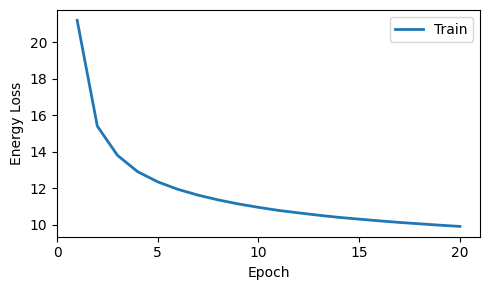

In [29]:
# ------------------------------
# Loss curve
# ------------------------------
epochs = np.arange(1, len(loss_array)+1)

plt.figure(figsize=(5, 3))

plt.plot(epochs, loss_array, linewidth=2, label='Train')

plt.xlabel("Epoch")
plt.ylabel("Energy Loss")

plt.xlim(0, 21)
plt.xticks([0, 5, 10, 15, 20])

plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [30]:
# ------------------------------
# Evaluation
# ------------------------------
model.eval()

batch_size = 16
K_eval = 6

preds_all = []
preds_mean = []
preds_std = []
preds_det = []

with torch.inference_mode():

    for i in range(0, X_test.shape[0], batch_size):

        X_batch = X_test[i:i+batch_size].to(device)
        Y_batch = Y_test[i:i+batch_size].to(device)

        B, _, H, W = X_batch.shape

        ensemble_preds = []
        for k in range(K_eval):
            z = torch.randn(B, model.module.latent_channels, H // 8, W // 8, device=device)
            pred = model(X_batch, Y_batch.shape[-2:], z=z)
            ensemble_preds.append(pred)

        preds = torch.stack(ensemble_preds, dim=0)

        preds = preds.permute(1, 0, 2, 3, 4)

        # Ensemble statistics
        pred_mean = preds.mean(dim=1)
        pred_std = preds.std(dim=1)

        # Deterministic prediction
        z0 = torch.zeros(B, model.module.latent_channels, H // 8, W // 8, device=device)
        pred_det = model(X_batch, Y_batch.shape[-2:], z=z0)

        preds_all.append(preds.cpu())
        preds_mean.append(pred_mean.cpu())
        preds_std.append(pred_std.cpu())
        preds_det.append(pred_det.cpu())

# Concatenate
preds_all = torch.cat(preds_all, dim=0)
Y_pred = torch.cat(preds_mean, dim=0)
Y_spread = torch.cat(preds_std, dim=0)
Y_pred_det = torch.cat(preds_det, dim=0)

# Convert back to physical units
Y_test_phys = Y_test * Y_std + Y_mean
Y_pred_phys = Y_pred * Y_std + Y_mean
Y_spread_phys = Y_spread * Y_std
Y_pred_det_phys = Y_pred_det * Y_std + Y_mean
preds_all_phys = preds_all * Y_std + Y_mean

# Bilinear baseline
sit_idx = 0
X_test_sit_phys = X_test[:, sit_idx:sit_idx+1] * X_std[:, sit_idx:sit_idx+1] + X_mean[:, sit_idx:sit_idx+1]
Y_base_phys = F.interpolate(X_test_sit_phys, size=Y_test.shape[-2:], mode="bilinear", align_corners=False).cpu()

print('Done!')

Done!


In [31]:
# ------------------------------
# Metrics
# ------------------------------

def mae(pred, truth):
    return torch.mean(torch.abs(pred - truth)).item()


def rmse(pred, truth):
    return torch.sqrt(torch.mean((pred - truth) ** 2)).item()


def grad_mae(pred, truth):
    dx_p = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dx_t = truth[:, :, :, 1:] - truth[:, :, :, :-1]
    dy_p = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dy_t = truth[:, :, 1:, :] - truth[:, :, :-1, :]
    grad_error = torch.mean(torch.abs(dx_p - dx_t)) + torch.mean(torch.abs(dy_p - dy_t))
    return grad_error.item()


def spread_skill_ratio(pred_mean, pred_std, truth):
    error = torch.abs(pred_mean - truth)
    return (pred_std.mean() / error.mean()).item()


metrics = [
    {
        "Method": "Bilinear",
        "MAE": mae(Y_base_phys, Y_test_phys),
        "RMSE": rmse(Y_base_phys, Y_test_phys),
        "Grad MAE": grad_mae(Y_base_phys, Y_test_phys),
        "Spread/Error": np.nan,
    }, {
        "Method": "Deterministic UNet",
        "MAE": mae(Y_pred_det_phys, Y_test_phys),
        "RMSE": rmse(Y_pred_det_phys, Y_test_phys),
        "Grad MAE": grad_mae(Y_pred_det_phys, Y_test_phys),
        "Spread/Error": np.nan,
    }, {
        "Method": "Stochastic UNet Mean",
        "MAE": mae(Y_pred_phys, Y_test_phys),
        "RMSE": rmse(Y_pred_phys, Y_test_phys),
        "Grad MAE": grad_mae(Y_pred_phys, Y_test_phys),
        "Spread/Error": spread_skill_ratio(Y_pred_phys, Y_spread_phys, Y_test_phys),
    }
]

metrics_df = pd.DataFrame(metrics).round(4)

print(metrics_df)

                 Method     MAE    RMSE  Grad MAE  Spread/Error
0              Bilinear  0.7147  1.2489    0.3604           NaN
1    Deterministic UNet  0.1431  0.2611    0.2514           NaN
2  Stochastic UNet Mean  0.1311  0.2454    0.2347         1.203


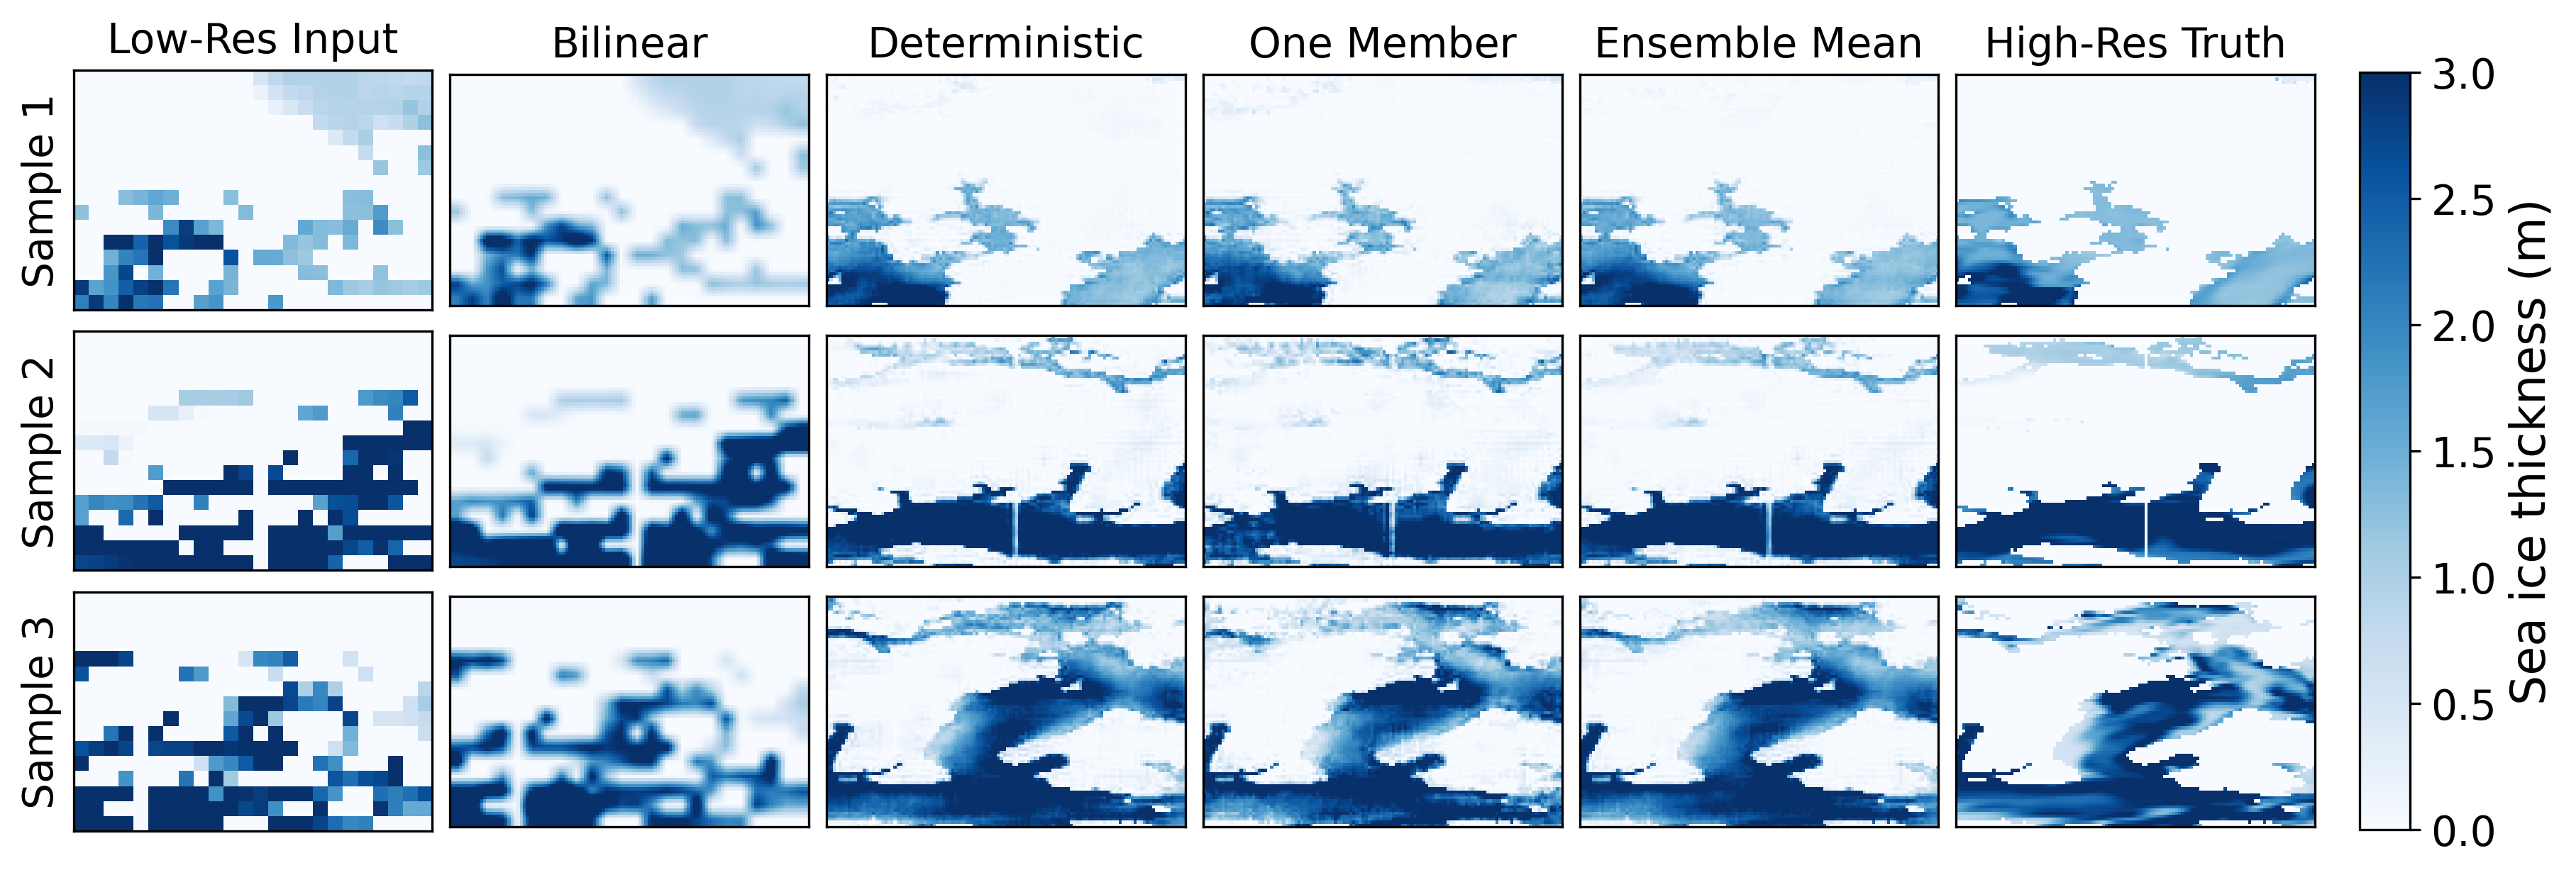

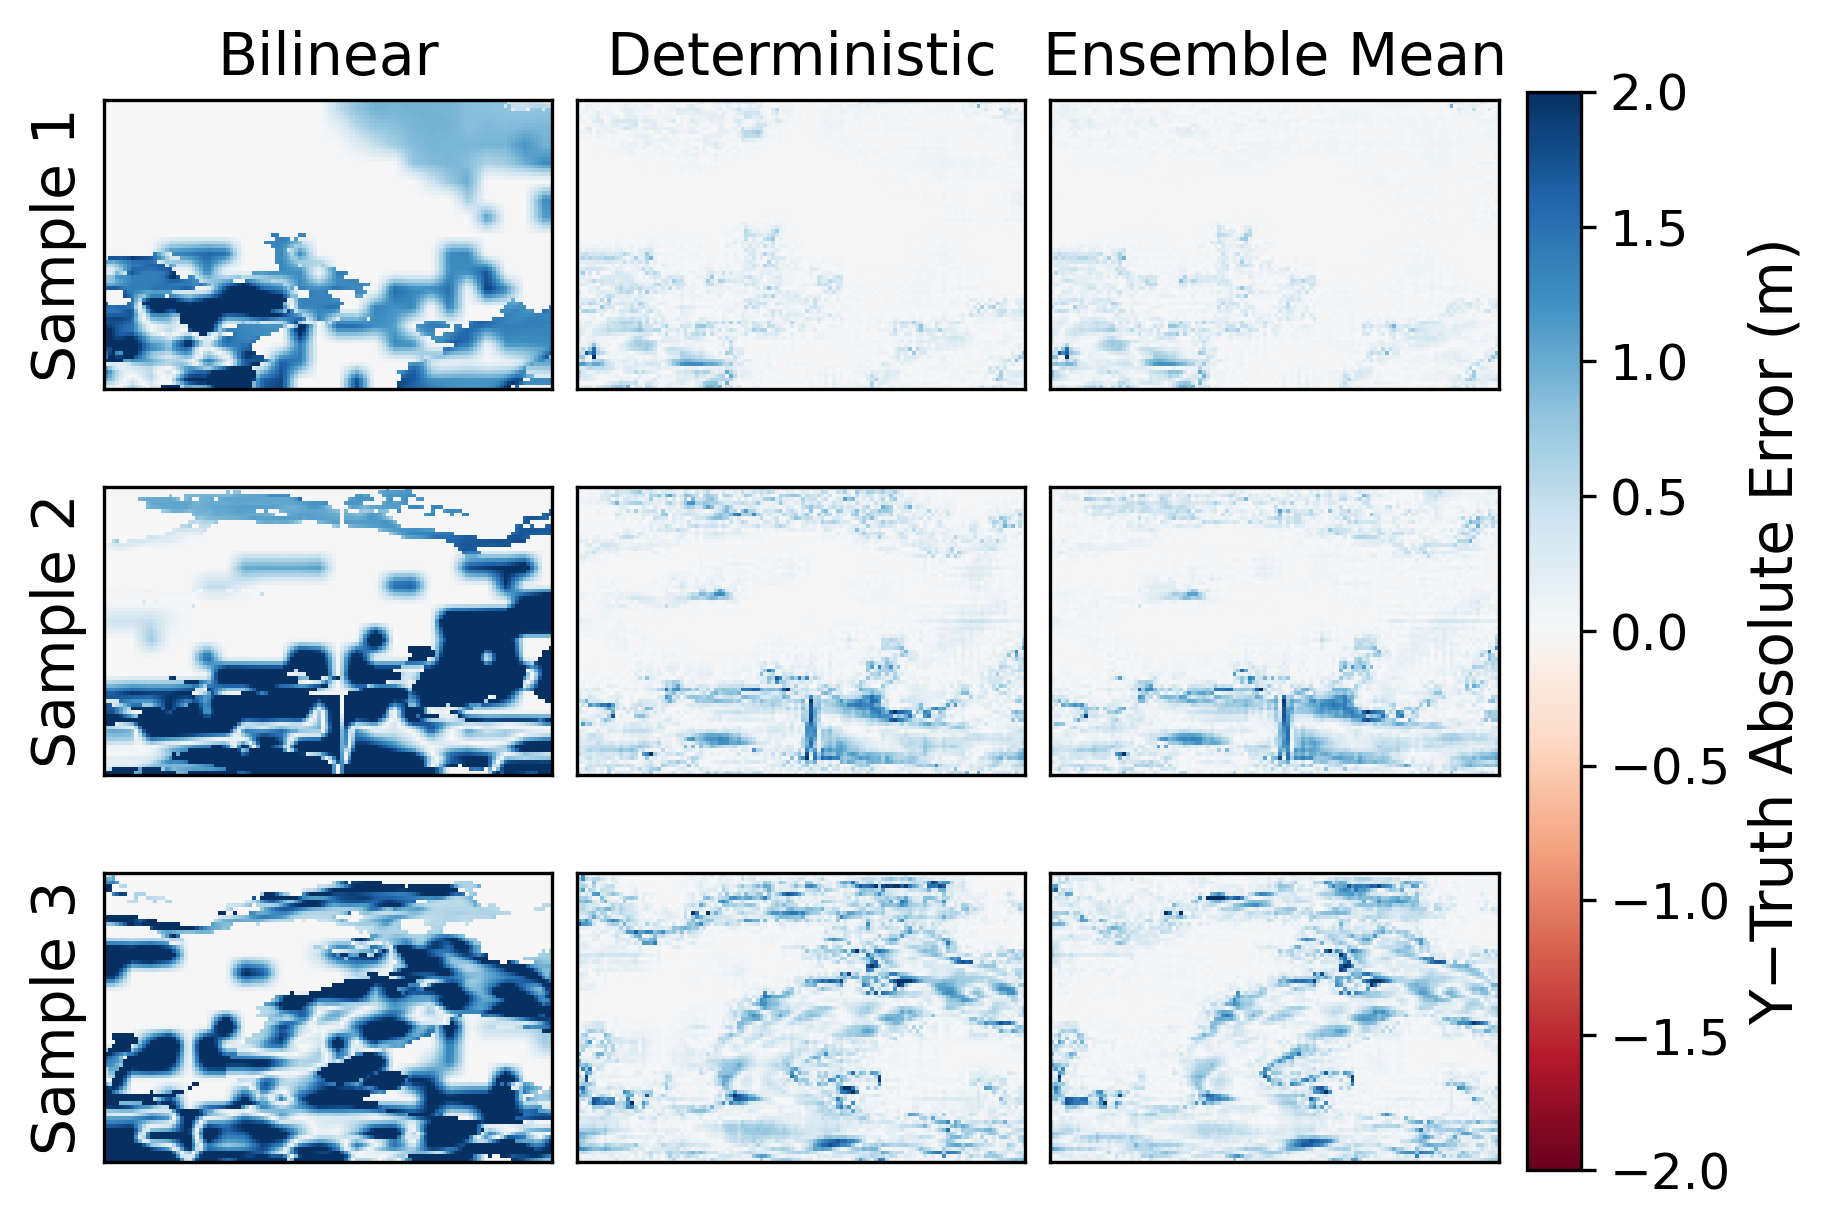

In [43]:
# ------------------------------
# Ensemble Figure
# ------------------------------
mem_idx = 4
num_samples = 3
idxs = np.random.choice(X_test.shape[0], num_samples, replace=False)

fig, axs = plt.subplots(3, 6, figsize=(12, 4), constrained_layout=True, dpi=300)

for row, idx in enumerate(idxs):

    lowres = X_test_sit_phys[idx, 0]
    bilinear = Y_base_phys[idx, 0]
    deterministic = Y_pred_det_phys[idx, 0]
    ens_full = preds_all_phys[idx]
    ens_mean = Y_pred_phys[idx, 0]
    truth = Y_test_phys[idx, 0]

    # Low-res
    im = axs[row, 0].imshow(lowres, cmap='Blues', vmin=0, vmax=3)
    axs[0, 0].set_title("Low-Res Input", fontsize=14)

    # Bilinear
    axs[row, 1].imshow(bilinear, cmap='Blues', vmin=0, vmax=3)
    axs[0, 1].set_title("Bilinear", fontsize=14)

    # Deterministic
    axs[row, 2].imshow(deterministic, cmap='Blues', vmin=0, vmax=3)
    axs[0, 2].set_title("Deterministic", fontsize=14)

    # Ensemble member
    axs[row, 3].imshow(ens_full[mem_idx, 0], cmap='Blues', vmin=0, vmax=3)
    axs[0, 3].set_title("One Member", fontsize=14)

    # Ensemble mean
    axs[row, 4].imshow(ens_mean, cmap='Blues', vmin=0, vmax=3)
    axs[0, 4].set_title("Ensemble Mean", fontsize=14)

    # Truth
    axs[row, 5].imshow(truth, cmap='Blues', vmin=0, vmax=3)
    axs[0, 5].set_title("High-Res Truth", fontsize=14)

    for col in range(6):
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])

    axs[0, 0].set_ylabel('Sample 1', fontsize=14)
    axs[1, 0].set_ylabel('Sample 2', fontsize=14)
    axs[2, 0].set_ylabel('Sample 3', fontsize=14)

cbar = fig.colorbar(im, ax=axs, aspect=15, shrink=0.99, pad=0.02)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Sea ice thickness (m)", fontsize=16)

plt.show()

# ------------------------------
# Error Figure
# ------------------------------
fig, axs = plt.subplots(3, 3, figsize=(6, 4), constrained_layout=True, dpi=300)

for row, idx in enumerate(idxs):

    bilinear = Y_base_phys[idx, 0].numpy()
    det = Y_pred_det_phys[idx, 0].numpy()
    ens = Y_pred_phys[idx, 0].numpy()
    truth = Y_test_phys[idx, 0].numpy()

    bilinear_ae = abs(bilinear - truth)
    det_ae = abs(det - truth)
    ens_ae = abs(ens - truth)

    # Bilinear
    im = axs[row, 0].imshow(bilinear_ae, cmap='RdBu', vmin=-2, vmax=2)
    axs[0, 0].set_title("Bilinear", fontsize=14)

    # Deterministic
    axs[row, 1].imshow(det_ae, cmap='RdBu', vmin=-2, vmax=2)
    axs[0, 1].set_title("Deterministic", fontsize=14)

    # Ensemble mean
    axs[row, 2].imshow(ens_ae, cmap='RdBu', vmin=-2, vmax=2)
    axs[0, 2].set_title("Ensemble Mean", fontsize=14)

    for col in range(3):
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])

    axs[0, 0].set_ylabel('Sample 1', fontsize=14)
    axs[1, 0].set_ylabel('Sample 2', fontsize=14)
    axs[2, 0].set_ylabel('Sample 3', fontsize=14)

cbar = fig.colorbar(im, ax=axs, aspect=20, shrink=0.95, pad=0.02)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Y−Truth Absolute Error (m)", fontsize=14)

plt.show()

#### Training loop (normal)

In [ ]:
# ------------------------------
# Training Loop
# ------------------------------

num_epochs = 20
batch_size = 16
loss_array = []

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0.0

    idx = torch.randperm(X_train.size(0))

    for i in range(0, X_train.size(0), batch_size):

        optimizer.zero_grad()

        batch_idx = idx[i:i+batch_size]
        X_batch = X_train[batch_idx].to(device, non_blocking=True)
        Y_batch = Y_train[batch_idx].to(device, non_blocking=True)
        Y_pred = model(X_batch, Y_batch.shape[-2:])

        if USE_MASKED_LOSS:
            mask_batch = F.interpolate(
                mask,
                size=Y_batch.shape[-2:],
                mode='nearest'
            )
            mask_batch = mask_batch.expand(Y_batch.size(0), 1, -1, -1).to(device)
            loss = masked_loss(Y_pred, Y_batch, mask_batch)
        else:
            loss = base_loss(Y_pred, Y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

        # Clean up after loop
        del X_batch, Y_batch, Y_pred, loss

    epoch_loss /= X_train.size(0)
    loss_array.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.6f}")

epochs = np.arange(1, len(loss_array)+1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, loss_array, marker='o', linestyle='-', color='C0', linewidth=2, markersize=6, label='Training Loss')

plt.title('UNet Training Loss per Epoch', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.xticks(epochs)
plt.xlim(0.5, len(epochs)+0.5)
plt.grid(alpha=0.25)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------
# Evaluation
# ------------------------------
model.eval()
batch_size = 16
preds = []

with torch.inference_mode():
    for i in range(0, X_test.shape[0], batch_size):

        X_batch = X_test[i:i+batch_size].to(device)
        Y_batch = Y_test[i:i+batch_size]

        Y_pred_batch = model(X_batch, Y_batch.shape[-2:])
        preds.append(Y_pred_batch.cpu())

Y_pred = torch.cat(preds, dim=0)
Y_pred_phys = Y_pred * Y_std + Y_mean
Y_test_phys = Y_test * Y_std + Y_mean

# ------------------------------
# Bilinear baseline
# ------------------------------
sit_idx = 0

X_test_sit_phys = (
    X_test[:, sit_idx:sit_idx+1] * X_std[:, sit_idx:sit_idx+1]
    + X_mean[:, sit_idx:sit_idx+1]
)

base = F.interpolate(
    X_test_sit_phys,
    size=Y_test.shape[-2:],
    mode="bilinear",
    align_corners=False
)

# ------------------------------
# Metrics
# ------------------------------
mse_cnn = ((Y_pred_phys - Y_test_phys)**2).mean().item()
mse_base = ((base - Y_test_phys)**2).mean().item()


def spatial_corr(y_true, y_pred):
    y_true_flat = y_true.reshape(y_true.shape[0], -1)
    y_pred_flat = y_pred.reshape(y_pred.shape[0], -1)

    corrs = []
    valid = 0
    total = y_true.shape[0]

    for i in range(y_true.shape[0]):

        std_true = np.std(y_true_flat[i])
        std_pred = np.std(y_pred_flat[i])

        # Skip bad patches
        if std_true > 0 and std_pred > 0:
            valid += 1
            corrs.append(np.corrcoef(y_true_flat[i], y_pred_flat[i])[0, 1])

    print(f"Valid patches: {valid}/{total}")

    return np.nanmean(corrs)


corr_cnn = spatial_corr(
    Y_test_phys.cpu().numpy(),
    Y_pred_phys.cpu().numpy()
)

corr_base = spatial_corr(
    Y_test_phys.cpu().numpy(),
    base.cpu().numpy()
)

print(f"\nCNN Test MSE         : {mse_cnn:.4f}")
print(f"Bilinear baseline MSE: {mse_base:.4f}")
print(f"\nCNN Test spatial correlation         : {corr_cnn:.4f}")
print(f"Bilinear baseline spatial correlation: {corr_base:.4f}")

In [ ]:
# ------------------------------
# Random samples for plotting
# ------------------------------
num_samples = 3
idxs = np.random.choice(X_test.shape[0], num_samples, replace=False)
cmap = 'Blues'
vmin, vmax = 0, 4

fig, axs = plt.subplots(num_samples, 4, figsize=(10, 6), constrained_layout=True)

for i, idx in enumerate(idxs):
    axs[i, 0].imshow(X_test[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 1].imshow(base[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 2].imshow(Y_pred_phys[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 3].imshow(Y_test_phys[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    for j in range(4):
        axs[i, j].axis('off')

axs[0, 0].set_title("Low-res Input")
axs[0, 1].set_title("Bilinear Interpolation")
axs[0, 2].set_title("UNet Prediction")
axs[0, 3].set_title("Hi-res Truth")

fig.colorbar(axs[0, 0].images[0], ax=axs, shrink=0.95, aspect=35, label='Sea ice thickness (m)')
plt.show()